# Upgrade Modelo 1: Pronóstico de Demanda (Avanzado)
En este notebook entrenaremos modelos avanzados de series temporales (XGBoost Regressor, SARIMAX, Prophet y Ridge Regressor) para pronosticar la demanda logística de 3 medicamentos a 7, 14 y 60 días.
Utilizamos datos históricos combinados con **variables exógenas del censo poblacional de riesgo** y **features a largo plazo**.

In [63]:
# Instalación de dependencias (Descomentar si es necesario)
# !pip install xgboost statsmodels prophet scikit-learn

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
import itertools
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import statsmodels.api as sm
from prophet import Prophet
from sklearn.linear_model import Ridge
import joblib

warnings.filterwarnings('ignore')

## 1. Preparación de Datos (Data Preparation)

In [ ]:
BASE_DIR = Path(".").resolve().parent
DATA_PATH = BASE_DIR / "datos" / "datos_modelo1" / "raw" / "aldimi_demand_dataset.csv"

df = pd.read_csv(DATA_PATH)
df['fecha'] = pd.to_datetime(df['fecha'])
df = df.sort_values('fecha').reset_index(drop=True)
print(f"Dataset cargado con {len(df)} registros. Desde {df['fecha'].min().date()} hasta {df['fecha'].max().date()}")

def preparar_datos_horizonte(df, drug, h):
    df_h = df.copy()
    
    # Target Acumulado
    target_col = f'{drug}_demand'
    df_h['target'] = df_h[target_col].rolling(window=h).sum().shift(-h)
    
    # Features Lags Corto y Largo Plazo
    df_h['demanda_hoy'] = df_h[target_col]
    df_h['promedio_semanal'] = df_h[target_col].rolling(window=7).mean()
    df_h['promedio_mensual'] = df_h[target_col].rolling(window=30).mean()
    df_h['promedio_trimestral'] = df_h[target_col].rolling(window=90).mean()
    df_h['lag_365'] = df_h[target_col].shift(365)
    
    df_h = df_h.dropna().copy()
    
    features = ['n_low', 'n_medium', 'n_high', 'dia_semana', 'es_fin_de_semana', 
                'demanda_hoy', 'promedio_semanal', 'promedio_mensual', 'promedio_trimestral', 'lag_365']
    
    #70% Train, 15% Val, 15% Test
    n = len(df_h)
    train_end = int(n * 0.70)
    val_end = int(n * 0.85)
    
    train = df_h.iloc[:train_end]
    val = df_h.iloc[train_end:val_end]
    test = df_h.iloc[val_end:]
    
    return train, val, test, features

Dataset cargado con 2106 registros. Desde 2014-01-02 hasta 2019-10-08


## 2. Funciones de Modelado y Tuning

In [66]:
def evaluate_metrics(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {'Model': model_name, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

def train_tune_xgboost(train, val, features):
    best_rmse = float('inf')
    best_model = None
    best_params = None
    
    for n_est in [10, 15, 25, 35, 40, 50, 75, 100]:
        for lr in [ 0.03, 0.04, 0.05, 0.06, 0.07, 0.1, 0.15, 0.2, 0.25]:
            for md in [2, 3, 4, 5]:
                model = XGBRegressor(n_estimators=n_est, learning_rate=lr, max_depth=md, random_state=42)
                model.fit(train[features], train['target'])
                preds = model.predict(val[features])
                rmse = np.sqrt(mean_squared_error(val['target'], preds))
                if rmse < best_rmse:
                    best_rmse = rmse
                    best_model = model
                    best_params = {'n_est': n_est, 'lr': lr, 'max_depth': md}
    return best_model, best_params

def train_tune_sarimax(train, val, features):
    best_rmse = float('inf')
    best_model_results = None
    best_order = None
    
    p = d = q = [0, 1]
    pdq = list(itertools.product(p, d, q))
    
    exog_train = train[features]
    exog_val = val[features]
    
    for param in pdq:
        try:
            model = sm.tsa.SARIMAX(train['target'].values, exog=exog_train.values, order=param, enforce_stationarity=False, enforce_invertibility=False)
            results = model.fit(disp=False)
            preds = results.forecast(steps=len(val), exog=exog_val.values)
            rmse = np.sqrt(mean_squared_error(val['target'], preds))
            
            if rmse < best_rmse:
                best_rmse = rmse
                best_model_results = results
                best_order = param
        except:
            continue
    return best_model_results, best_order

def train_tune_prophet(train, val, features):
    df_prophet_train = train[['fecha', 'target'] + features].rename(columns={'fecha': 'ds', 'target': 'y'})
    df_prophet_val = val[['fecha'] + features].rename(columns={'fecha': 'ds'})
    
    best_rmse = float('inf')
    best_model = None
    best_params = None
    
    for changepoint in [0.05, 0.1]:
        m = Prophet(changepoint_prior_scale=changepoint)
        for f in features:
            m.add_regressor(f)
        
        m.fit(df_prophet_train)
        forecast = m.predict(df_prophet_val)
        preds = forecast['yhat'].values
        rmse = np.sqrt(mean_squared_error(val['target'], preds))
        
        if rmse < best_rmse:
            best_rmse = rmse
            best_model = m
            best_params = {'changepoint': changepoint}
            
    return best_model, best_params

def train_tune_ridge(train, val, features):
    best_rmse = float('inf')
    best_model = None
    best_params = None
    
    y_train = train['target'].values
    
    alphas = [0.1, 1.0, 10.0, 100.0, 1000.0]
    for a in alphas:
        model = Ridge(alpha=a)
        model.fit(train[features], y_train)
        preds = model.predict(val[features])
        rmse = np.sqrt(mean_squared_error(val['target'], preds))
        
        if rmse < best_rmse:
            best_rmse = rmse
            best_model = model
            best_params = {'alpha': a}
            
    return best_model, best_params

## Definición de Iteraciones

In [67]:
drugs = ['N02BE', 'N05B', 'M01AB']
horizons = [7, 14, 60]

## 3. Tuning de XGBoost

In [68]:
xgb_results = {}
for drug in drugs:
    for h in horizons:
        print(f"Entrenando XGBoost para {drug} a {h} días...")
        train, val, test, features = preparar_datos_horizonte(df, drug, h)
        model, params = train_tune_xgboost(train, val, features)
        preds = model.predict(val[features])
        metrics = evaluate_metrics(val['target'], preds, "XGBoost")
        metrics['Params'] = str(params)
        xgb_results[(drug, h)] = {'model': model, 'metrics': metrics}

print("\nTuning de XGBoost completado. Mejores métricas por iteración:")
xgb_summary = pd.DataFrame([ {**{'Drug': d, 'Horizon': h}, **v['metrics']} for (d, h), v in xgb_results.items() ])
display(xgb_summary)

Entrenando XGBoost para N02BE a 7 días...
Entrenando XGBoost para N02BE a 14 días...
Entrenando XGBoost para N02BE a 60 días...
Entrenando XGBoost para N05B a 7 días...
Entrenando XGBoost para N05B a 14 días...
Entrenando XGBoost para N05B a 60 días...
Entrenando XGBoost para M01AB a 7 días...
Entrenando XGBoost para M01AB a 14 días...
Entrenando XGBoost para M01AB a 60 días...

Tuning de XGBoost completado. Mejores métricas por iteración:


,Drug,Horizon,Model,MAE,MSE,RMSE,R2,Params
0,N02BE,7,XGBoost,213.112029,7.377150e+04,271.609103,0.587882,"{'n_est': 50, 'lr': 0.06, 'max_depth': 2}"
1,N02BE,14,XGBoost,322.223438,1.686791e+05,410.705626,0.718361,"{'n_est': 10, 'lr': 0.25, 'max_depth': 2}"
2,N02BE,60,XGBoost,1381.606799,3.178228e+06,1782.758498,0.588422,"{'n_est': 100, 'lr': 0.07, 'max_depth': 3}"
3,N05B,7,XGBoost,34.768257,1.922842e+03,43.850225,-0.452714,"{'n_est': 10, 'lr': 0.1, 'max_depth': 3}"
4,N05B,14,XGBoost,47.481557,3.642958e+03,60.356919,-0.798890,"{'n_est': 35, 'lr': 0.06, 'max_depth': 2}"
5,N05B,60,XGBoost,266.522691,7.668888e+04,276.927571,-9.727283,"{'n_est': 10, 'lr': 0.03, 'max_depth': 5}"
6,M01AB,7,XGBoost,33.513589,1.643404e+03,40.538925,0.158934,"{'n_est': 25, 'lr': 0.05, 'max_depth': 2}"
7,M01AB,14,XGBoost,50.969163,4.044899e+03,63.599520,0.195635,"{'n_est': 10, 'lr': 0.1, 'max_depth': 2}"
8,M01AB,60,XGBoost,111.852121,1.802253e+04,134.248012,0.051590,"{'n_est': 15, 'lr': 0.06, 'max_depth': 2}"


## 4. Tuning de SARIMAX

In [ ]:
sarimax_results = {}
for drug in drugs:
    for h in horizons:
        print(f"Entrenando SARIMAX para {drug} a {h} días...")
        train, val, test, features = preparar_datos_horizonte(df, drug, h)
        model, order = train_tune_sarimax(train, val, features)
        preds = model.forecast(steps=len(val), exog=val[features].values)
        metrics = evaluate_metrics(val['target'], preds, "SARIMAX")
        metrics['Params'] = f"order={order}"
        sarimax_results[(drug, h)] = {'model': model, 'metrics': metrics}

print("\nTuning de SARIMAX completado. Mejores métricas por iteración:")
sarimax_summary = pd.DataFrame([ {**{'Drug': d, 'Horizon': h}, **v['metrics']} for (d, h), v in sarimax_results.items() ])
display(sarimax_summary)

Entrenando SARIMAX para N02BE a 7 días...


## 5. Tuning de Prophet

In [ ]:
prophet_results = {}
for drug in drugs:
    for h in horizons:
        print(f"Entrenando Prophet para {drug} a {h} días...")
        train, val, test, features = preparar_datos_horizonte(df, drug, h)
        model, params = train_tune_prophet(train, val, features)
        df_prophet_val = val[['fecha'] + features].rename(columns={'fecha': 'ds'})
        preds = model.predict(df_prophet_val)['yhat'].values
        metrics = evaluate_metrics(val['target'], preds, "Prophet")
        metrics['Params'] = str(params)
        prophet_results[(drug, h)] = {'model': model, 'metrics': metrics}

print("\nTuning de Prophet completado. Mejores métricas por iteración:")
prophet_summary = pd.DataFrame([ {**{'Drug': d, 'Horizon': h}, **v['metrics']} for (d, h), v in prophet_results.items() ])
display(prophet_summary)

Entrenando Prophet para N02BE a 7 días...


13:28:01 - cmdstanpy - INFO - Chain [1] start processing
13:28:01 - cmdstanpy - INFO - Chain [1] done processing
13:28:01 - cmdstanpy - INFO - Chain [1] start processing
13:28:02 - cmdstanpy - INFO - Chain [1] done processing


Entrenando Prophet para N02BE a 14 días...


13:28:02 - cmdstanpy - INFO - Chain [1] start processing
13:28:02 - cmdstanpy - INFO - Chain [1] done processing
13:28:03 - cmdstanpy - INFO - Chain [1] start processing
13:28:03 - cmdstanpy - INFO - Chain [1] done processing


Entrenando Prophet para N02BE a 60 días...


...

13:28:12 - cmdstanpy - INFO - Chain [1] start processing
13:28:12 - cmdstanpy - INFO - Chain [1] done processing
13:28:13 - cmdstanpy - INFO - Chain [1] start processing
13:28:13 - cmdstanpy - INFO - Chain [1] done processing


Entrenando Prophet para M01AB a 60 días...


13:28:13 - cmdstanpy - INFO - Chain [1] start processing
13:28:14 - cmdstanpy - INFO - Chain [1] done processing
13:28:14 - cmdstanpy - INFO - Chain [1] start processing
13:28:16 - cmdstanpy - INFO - Chain [1] done processing



Tuning de Prophet completado. Mejores métricas por iteración:


,Drug,Horizon,Model,MAE,MSE,RMSE,R2,Params
0,N02BE,7,Prophet,190.709262,6.054206e+04,246.052963,0.661787,{'changepoint': 0.1}
1,N02BE,14,Prophet,267.449109,1.309267e+05,361.837986,0.781395,{'changepoint': 0.05}
2,N02BE,60,Prophet,1026.305116,1.303520e+06,1141.718121,0.831195,{'changepoint': 0.05}
3,N05B,7,Prophet,33.044787,1.695507e+03,41.176540,-0.280962,{'changepoint': 0.05}
4,N05B,14,Prophet,63.418621,6.224325e+03,78.894391,-2.073567,{'changepoint': 0.05}
5,N05B,60,Prophet,434.670259,2.353869e+05,485.166870,-31.926049,{'changepoint': 0.05}
6,M01AB,7,Prophet,34.397981,2.043798e+03,45.208388,-0.045981,{'changepoint': 0.1}
7,M01AB,14,Prophet,57.330864,5.303305e+03,72.823795,-0.054611,{'changepoint': 0.05}
8,M01AB,60,Prophet,138.864309,3.460388e+04,186.021175,-0.820981,{'changepoint': 0.05}


## 6. Tuning de Ridge Regressor

In [ ]:
ridge_results = {}
for drug in drugs:
    for h in horizons:
        print(f"Entrenando Ridge Regressor para {drug} a {h} días...")
        train, val, test, features = preparar_datos_horizonte(df, drug, h)
        model, params = train_tune_ridge(train, val, features)
        preds = model.predict(val[features])
        metrics = evaluate_metrics(val['target'], preds, "Ridge")
        metrics['Params'] = str(params)
        ridge_results[(drug, h)] = {'model': model, 'metrics': metrics}

print("\nTuning de Ridge Regressor completado. Mejores métricas por iteración:")
ridge_summary = pd.DataFrame([ {**{'Drug': d, 'Horizon': h}, **v['metrics']} for (d, h), v in ridge_results.items() ])
display(ridge_summary)

Entrenando Ridge Regressor para N02BE a 7 días...
Entrenando Ridge Regressor para N02BE a 14 días...
Entrenando Ridge Regressor para N02BE a 60 días...
Entrenando Ridge Regressor para N05B a 7 días...
Entrenando Ridge Regressor para N05B a 14 días...
Entrenando Ridge Regressor para N05B a 60 días...
Entrenando Ridge Regressor para M01AB a 7 días...
Entrenando Ridge Regressor para M01AB a 14 días...
Entrenando Ridge Regressor para M01AB a 60 días...

Tuning de Ridge Regressor completado. Mejores métricas por iteración:


,Drug,Horizon,Model,MAE,MSE,RMSE,R2,Params
0,N02BE,7,Ridge,211.442333,7.895381e+04,280.987207,0.558932,{'alpha': 1000.0}
1,N02BE,14,Ridge,369.952780,2.325438e+05,482.227908,0.611728,{'alpha': 1000.0}
2,N02BE,60,Ridge,1853.182904,4.912617e+06,2216.442342,0.363819,{'alpha': 1000.0}
3,N05B,7,Ridge,34.978787,1.927930e+03,43.908200,-0.456558,{'alpha': 1000.0}
4,N05B,14,Ridge,51.405297,4.104608e+03,64.067218,-1.026852,{'alpha': 1000.0}
5,N05B,60,Ridge,316.159995,1.157012e+05,340.148854,-15.184354,{'alpha': 1000.0}
6,M01AB,7,Ridge,32.902727,1.561770e+03,39.519238,0.200713,{'alpha': 1000.0}
7,M01AB,14,Ridge,51.266192,3.948066e+03,62.833637,0.214891,{'alpha': 10.0}
8,M01AB,60,Ridge,147.737915,2.915243e+04,170.740817,-0.534106,{'alpha': 1000.0}


## 7. Selección Final y Prueba (Test Set)
Comparamos las 4 variantes, seleccionamos al ganador y medimos su error final en los datos no vistos.


Resultados Finales para N02BE a 7 días


,Model,MAE,MSE,RMSE,R2,Params
0,XGBoost,213.112029,73771.504573,271.609103,0.587882,"{'n_est': 50, 'lr': 0.06, 'max_depth': 2}"
1,SARIMAX,211.960358,79366.314586,281.720277,0.556628,"order=(0, 0, 0)"
2,Prophet,190.709262,60542.060659,246.052963,0.661787,{'changepoint': 0.1}
3,Ridge,211.442333,78953.810240,280.987207,0.558932,{'alpha': 1000.0}


🏆 Seleccionando: Prophet


,Model,MAE,MSE,RMSE,R2
0,TEST Prophet,328.461197,134654.465684,366.952948,0.451791


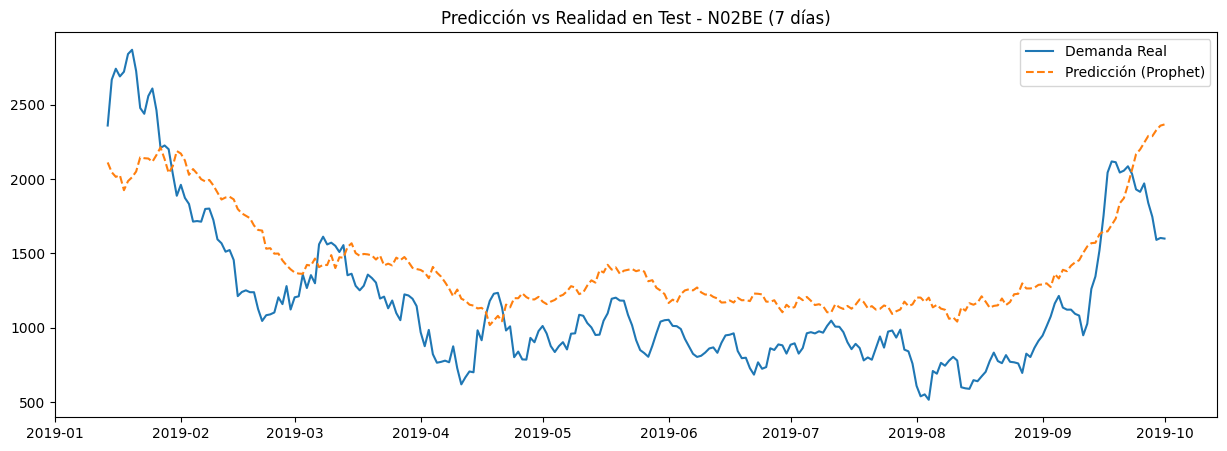

FileNotFoundError: [Errno 2] No such file or directory: '../modelos/modelosfinales/modelo1_demanda_N02BE_7dias_avanzado.json'

In [ ]:
os.makedirs('../modelos', exist_ok=True)

for drug in drugs:
    for h in horizons:
        print(f"\n{'='*50}")
        print(f"Resultados Finales para {drug} a {h} días")
        print(f"{'='*50}")
        
        # Juntar métricas
        xgb_m = xgb_results[(drug, h)]['metrics']
        sarimax_m = sarimax_results[(drug, h)]['metrics']
        prophet_m = prophet_results[(drug, h)]['metrics']
        ridge_m = ridge_results[(drug, h)]['metrics']
        
        metrics_df = pd.DataFrame([xgb_m, sarimax_m, prophet_m, ridge_m])
        display(metrics_df)
        
        # Seleccionar el mejor
        best_model_name = metrics_df.loc[metrics_df['RMSE'].idxmin()]['Model']
        print(f"Seleccionando: {best_model_name}")
        
        train, val, test, features = preparar_datos_horizonte(df, drug, h)
        
        # Predecir en Test
        if best_model_name == "XGBoost":
            final_model = xgb_results[(drug, h)]['model']
            test_preds = final_model.predict(test[features])
        elif best_model_name == "SARIMAX":
            final_model = sarimax_results[(drug, h)]['model']
            test_preds = final_model.forecast(steps=len(test), exog=test[features].values)
        elif best_model_name == "Prophet":
            final_model = prophet_results[(drug, h)]['model']
            df_prophet_test = test[['fecha'] + features].rename(columns={'fecha': 'ds'})
            test_preds = final_model.predict(df_prophet_test)['yhat'].values
        else: 
            final_model = ridge_results[(drug, h)]['model']
            test_preds = final_model.predict(test[features])
            
        test_metrics = evaluate_metrics(test['target'], test_preds, f"TEST {best_model_name}")
        display(pd.DataFrame([test_metrics]))
        
        # Gráfica
        plt.figure(figsize=(15, 5))
        plt.plot(test['fecha'], test['target'], label='Demanda Real')
        plt.plot(test['fecha'], test_preds, label=f'Predicción ({best_model_name})', linestyle='--')
        plt.title(f'Predicción vs Realidad en Test - {drug} ({h} días)')
        plt.legend()
        plt.show()
        
        # Exportar modelo
        model_path = f"../modelos/modelosfinales/modelo1_demanda_{drug}_{h}dias_avanzado.joblib"
        if best_model_name != "Prophet":
            joblib.dump(final_model, model_path)
        else:
            import json
            from prophet.serialize import model_to_json
            with open(f"../modelos/modelosfinales/modelo1_demanda_{drug}_{h}dias_avanzado.json", 'w') as fout:
                json.dump(model_to_json(final_model), fout)
        print(f"Modelo exportado correctamente en /modelos/modelosfinales")
